# 1 Primeira EDA & Feature Extractions Óbvias

Conhecendo o Dataset e fazendo limpezas óbvias antes de fazer uma EDA mais completa nas features

## 1. EDA Genérico - ufc-master.csv

Objetivo: entender rapidamente o tamanho da base, o periodo coberto, quais variaveis existem e alguns recortes simples do `ufc-master.csv`.


In [1]:
from pathlib import Path

import pandas as pd

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)

csv_path = Path('ufc-master.csv')
df = pd.read_csv(csv_path, parse_dates=['date'])

colunas_com_indice = pd.DataFrame(
    [{'idx': i, 'coluna': col} for i, col in enumerate(df.columns)]
)

n_blocos = 4
colunas_lado_a_lado = pd.concat(
    [
        colunas_com_indice.iloc[i::n_blocos].reset_index(drop=True)
        .rename(columns={'idx': f'idx_{i+1}', 'coluna': f'coluna_{i+1}'})
        for i in range(n_blocos)
    ],
    axis=1
)

display(colunas_lado_a_lado)    
df.head()


,idx_1,coluna_1,idx_2,coluna_2,idx_3,coluna_3,idx_4,coluna_4
0,0,R_fighter,1,B_fighter,2.0,R_odds,3.0,B_odds
1,4,R_ev,5,B_ev,6.0,date,7.0,location
2,8,country,9,Winner,10.0,title_bout,11.0,weight_class
3,12,gender,13,no_of_rounds,14.0,B_current_lose_streak,15.0,B_current_win_streak
4,16,B_draw,17,B_avg_SIG_STR_landed,18.0,B_avg_SIG_STR_pct,19.0,B_avg_SUB_ATT
5,20,B_avg_TD_landed,21,B_avg_TD_pct,22.0,B_longest_win_streak,23.0,B_losses
6,24,B_total_rounds_fought,25,B_total_title_bouts,26.0,B_win_by_Decision_Majority,27.0,B_win_by_Decision_Split
7,28,B_win_by_Decision_Unanimous,29,B_win_by_KO/TKO,30.0,B_win_by_Submission,31.0,B_win_by_TKO_Doctor_Stoppage
8,32,B_wins,33,B_Stance,34.0,B_Height_cms,35.0,B_Reach_cms
9,36,B_Weight_lbs,37,R_current_lose_streak,38.0,R_current_win_streak,39.0,R_draw


,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,B_match_weightclass_rank,R_match_weightclass_rank,R_Women's Flyweight_rank,R_Women's Featherweight_rank,R_Women's Strawweight_rank,R_Women's Bantamweight_rank,R_Heavyweight_rank,R_Light Heavyweight_rank,R_Middleweight_rank,R_Welterweight_rank,R_Lightweight_rank,R_Featherweight_rank,R_Bantamweight_rank,R_Flyweight_rank,R_Pound-for-Pound_rank,B_Women's Flyweight_rank,B_Women's Featherweight_rank,B_Women's Strawweight_rank,B_Women's Bantamweight_rank,B_Heavyweight_rank,B_Light Heavyweight_rank,B_Middleweight_rank,B_Welterweight_rank,B_Lightweight_rank,B_Featherweight_rank,B_Bantamweight_rank,B_Flyweight_rank,B_Pound-for-Pound_rank,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,False,Middleweight,MALE,5,0,3,0,3.52,0.44,0.9,1.45,0.30,4,2,18,0,0,0,1,4,2,0,7,Orthodox,187.96,190.50,185,3,0,0,4.03,0.48,0.1,0.05,0.09,9,5,66,12,0,1,7,5,0,0,13,Switch,193.04,203.20,185,36,29,-3,3,-5,-6,-3,-48,-12,-1,2,-5.08,-12.70,-7,-0.51,0.8,1.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KO/TKO,Punches,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,False,Women's Flyweight,FEMALE,3,0,7,0,4.56,0.53,0.1,1.56,0.45,7,2,34,0,0,2,4,5,0,0,11,Switch,165.10,165.10,125,2,0,1,4.11,0.41,0.7,0.40,0.35,5,5,45,3,0,1,5,0,2,0,8,Orthodox,165.10,167.64,125,32,27,-2,7,2,3,-3,-11,-3,5,-2,0.00,-2.54,-5,0.45,-0.6,1.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KO/TKO,Punch,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,False,Welterweight,MALE,3,3,0,0,5.11,0.43,0.6,1.06,0.30,2,10,40,0,0,0,2,4,2,0,8,Orthodox,182.88,193.04,170,0,3,0,2.02,0.40,1.0,3.11,0.47,4,7,47,1,0,0,6,0,8,0,14,Southpaw,185.42,190.50,170,38,36,3,-3,-2,-6,3,-7,-1,4,-6,-2.54,2.54,-2,3.09,-0.4,-2.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SUB,Rear Naked Choke,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,False,Featherweight,MALE,3,0,1,0,8.67,0.64,0.0,0.00,0.00,1,0,1,0,0,0,0,1,0,0,1,Orthodox,175.26,182.88,145,1,0,0,6.18,0.48,0.7,1.73,0.43,3,8,36,0,0,2,1,3,4,0,10,Southpaw,185.42,187.96,145,36,30,-1,1,-2,-9,-8,-35,0,-2,-4,-10.16,-5.08,-6,2.49,-0.7,-1.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

### 1.1 Quanto dado tenho?

In [2]:
resumo_base = pd.DataFrame({
    'metrica': [
        'linhas',
        'colunas',
        'tamanho_csv_mb',
        'data_inicial',
        'data_final',
        'lutadores_unicos_aprox'
    ],
    'valor': [
        len(df),
        df.shape[1],
        round(csv_path.stat().st_size / 1024**2, 2),
        df['date'].min().date(),
        df['date'].max().date(),
        pd.concat([df['R_fighter'], df['B_fighter']]).nunique()
    ]
})

resumo_base


,metrica,valor
0,linhas,7177
1,colunas,118
2,tamanho_csv_mb,3.05
3,data_inicial,2010-03-21
4,data_final,2026-03-28
5,lutadores_unicos_aprox,2241


### 1.2 Quais tipos de colunas existem?

In [3]:
df.dtypes.astype(str).value_counts().rename_axis('tipo').reset_index(name='qtd_colunas')

,tipo,qtd_colunas
0,float64,60
1,int64,43
2,str,13
3,datetime64[us],1
4,bool,1


### 1.3 Recortes basicos da base

In [4]:
recortes = {
    'genero': df['gender'].value_counts(dropna=False),
    'categorias_mais_frequentes': df['weight_class'].value_counts(dropna=False).head(12),
    'vencedor_red_blue': df['Winner'].value_counts(dropna=False),
    'formas_de_vitoria': df['finish'].value_counts(dropna=False).head(12),
    'paises_mais_frequentes': df['country'].value_counts(dropna=False).head(12)
}

for nome, serie in recortes.items():
    print(f'\n{nome}')
    display(serie)



genero


gender
MALE      6283
FEMALE     894
Name: count, dtype: int64


categorias_mais_frequentes


weight_class
Lightweight             1160
Welterweight            1097
Middleweight             873
Featherweight            833
Bantamweight             753
Light Heavyweight        551
Heavyweight              541
Flyweight                404
Women's Strawweight      359
Women's Flyweight        268
Women's Bantamweight     237
Catch Weight              71
Name: count, dtype: int64


vencedor_red_blue


Winner
Red           4145
Blue          3024
Draw             5
No Contest       3
Name: count, dtype: int64


formas_de_vitoria


finish
U-DEC         2681
KO/TKO        2223
SUB           1260
S-DEC          699
NaN            238
M-DEC           52
DQ              18
CNC              3
Overturned       3
Name: count, dtype: int64


paises_mais_frequentes


country
 USA                    2450
USA                     2331
 Brazil                  400
 Canada                  337
United Arab Emirates     229
 United Kingdom          165
 Australia               160
United Kingdom            95
Australia                 73
 Sweden                   72
 Mexico                   70
 China                    61
Name: count, dtype: int64

### 1.4 Faltantes: onde a base tem buracos?

In [5]:
faltantes = (
    df.isna().sum()
    .sort_values(ascending=False)
    .rename('qtd_faltante')
    .to_frame()
)
faltantes['pct_faltante'] = (faltantes['qtd_faltante'] / len(df) * 100).round(2)

faltantes.query('qtd_faltante > 0').head(30)

,qtd_faltante,pct_faltante
B_Women's Featherweight_rank,7176,99.99
R_Women's Featherweight_rank,7168,99.87
B_Pound-for-Pound_rank,7096,98.87
B_Women's Flyweight_rank,7092,98.82
R_Women's Flyweight_rank,7066,98.45
B_Women's Strawweight_rank,7063,98.41
B_Women's Bantamweight_rank,7057,98.33
B_Welterweight_rank,7046,98.17
B_Light Heavyweight_rank,7044,98.15
B_Featherweight_rank,7043,98.13


### 1.5 Volume de lutas ao longo do tempo

C:\Users\joaopjpc\AppData\Local\Temp\ipykernel_7252\2362099772.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(ano=df['date'].dt.year)


,ano,qtd_lutas
0,2010,210
1,2011,295
2,2012,333
3,2013,376
4,2014,494
5,2015,464
6,2016,483
7,2017,440
8,2018,471
9,2019,507


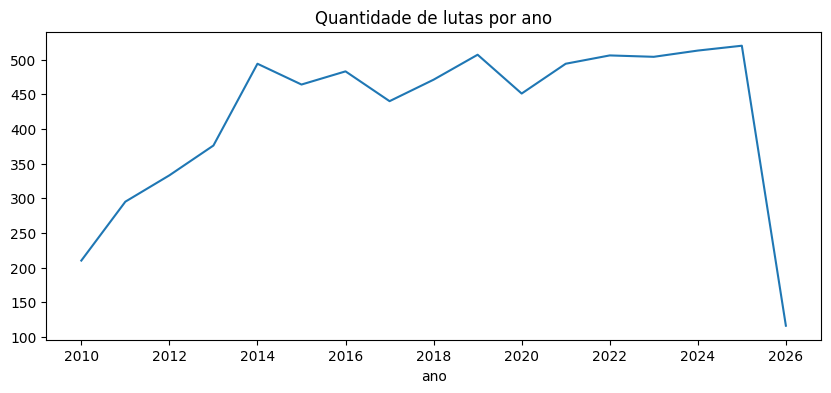

In [6]:
lutas_por_ano = (
    df.assign(ano=df['date'].dt.year)
    .groupby('ano')
    .size()
    .rename('qtd_lutas')
    .reset_index()
)

display(lutas_por_ano.tail(20))
lutas_por_ano.plot(x='ano', y='qtd_lutas', figsize=(10, 4), title='Quantidade de lutas por ano', legend=False);


## 1.2 Feature Extractions mais Óbvios


### 1.2.1 Colunas escolhidas


Vou enxutar o dataset, removendo colunas que não agregam informação importante sobre a luta em si, mantendo todas as variáveis sobre estatísticas dos lutadores antes da luta. Vou tentar usar as colunas "diff" que já existem no dataset, e representam diferenças de estattísticas pré luta do lutador. Essa medida é melhor pra modelos lineares, já que quando usamos features são correlacionadas ou quase linearmente dependentes, os coeficientes de modelos lineares podem ficar sensíveis/instáveis por multicolinearidade. **(investigar melhor essa escolha de usar só diff - talvez usar ambas seja uma possibilidade).**

Vale dizer que, pra uma abordagem que NÃO USE as estatísticas como diff, esse passo terá que ser totalmente repensado. Talvez já valhe a pena trazer tb as estatisticas absolutas pra testar outros algoritmos. Isso deve ser pensado e investigado

In [7]:
colunas_eda = [
    'date',
    'R_fighter',
    'B_fighter',    
    'Winner',
    'weight_class',
    'gender',
    'no_of_rounds',

    'win_streak_dif',
    'longest_win_streak_dif',
    'lose_streak_dif',
    'win_dif',
    'loss_dif',
    'total_round_dif',
    'total_title_bout_dif',
    'ko_dif',
    'sub_dif',
    'height_dif',
    'reach_dif',
    'age_dif',
    'sig_str_dif',
    'avg_sub_att_dif',
    'avg_td_dif',

    

    'B_wins',
    'B_losses',

    'B_avg_SIG_STR_pct',
    'B_avg_TD_pct',
    'B_Stance',

    'R_wins',
    'R_losses',

    'R_avg_SIG_STR_pct',
    'R_avg_TD_pct',
    'R_Stance',
]


### 1.2.2 Conferencia das colunas


In [8]:
colunas_faltantes = sorted(set(colunas_eda) - set(df.columns))

if colunas_faltantes:
    raise ValueError(f'Colunas nao encontradas no CSV: {colunas_faltantes}')

resumo_colunas_eda = pd.DataFrame({
    'metrica': ['colunas_dataset_original', 'colunas_selecionadas', 'colunas_removidas'],
    'valor': [df.shape[1], len(colunas_eda), df.shape[1] - len(colunas_eda)]
})

resumo_colunas_eda


,metrica,valor
0,colunas_dataset_original,118
1,colunas_selecionadas,32
2,colunas_removidas,86


### 1.2.3 Criando o dataset limpo


In [9]:
df_eda = df.loc[:, colunas_eda].copy()

print(f'Dataset original: {df.shape[0]:,} linhas x {df.shape[1]:,} colunas')
print(f'Dataset limpo para EDA: {df_eda.shape[0]:,} linhas x {df_eda.shape[1]:,} colunas')

df_eda.head()


Dataset original: 7,177 linhas x 118 colunas
Dataset limpo para EDA: 7,177 linhas x 32 colunas


,date,R_fighter,B_fighter,Winner,weight_class,gender,no_of_rounds,win_streak_dif,longest_win_streak_dif,lose_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,B_wins,B_losses,B_avg_SIG_STR_pct,B_avg_TD_pct,B_Stance,R_wins,R_losses,R_avg_SIG_STR_pct,R_avg_TD_pct,R_Stance
0,2026-03-28,Israel Adesanya,Joe Pyfer,Blue,Middleweight,MALE,5,3,-5,-3,-6,-3,-48,-12,-1,2,-5.08,-12.70,-7,-0.51,0.8,1.40,7,2,0.44,0.30,Orthodox,13,5,0.48,0.09,Switch
1,2026-03-28,Alexa Grasso,Maycee Barber,Red,Women's Flyweight,FEMALE,3,7,2,-2,3,-3,-11,-3,5,-2,0.00,-2.54,-5,0.45,-0.6,1.16,11,2,0.53,0.45,Switch,8,5,0.41,0.35,Orthodox
2,2026-03-28,Michael Chiesa,Niko Price,Red,Welterweight,MALE,3,-3,-2,3,-6,3,-7,-1,4,-6,-2.54,2.54,-2,3.09,-0.4,-2.05,8,10,0.43,0.30,Orthodox,14,7,0.40,0.47,Southpaw
3,2026-03-28,Julian Erosa,Lerryan Douglas,Blue,Featherweight,MALE,3,1,-2,-1,-9,-8,-35,0,-2,-4,-10.16,-5.08,-6,2.49,-0.7,-1.73,1,0,0.64,0.00,Orthodox,10,8,0.48,0.43,Southpaw
4,2026-03-28,Mansur Abdul-Malik,Yousri Belgaroui,Blue,Middleweight,MALE,3,-2,-1,0,-2,1,0,0,-1,-1,10.16,-2.54,5,2.82,-0.3,-1.36,2,1,0.64,1.00,Orthodox,4,0,0.44,0.41,Orthodox


### 1.2.4 Ajuste de tipos


In [10]:
colunas_categoricas = ['R_fighter', 'B_fighter', 'Winner', 'weight_class', 'gender', 'B_Stance', 'R_Stance']
colunas_numericas = df_eda.columns.difference(['date', *colunas_categoricas]) # todas as colunas que n?o s?o data, categ?ricas ou booleanas s?o num?ricas

df_eda[colunas_categoricas] = df_eda[colunas_categoricas].apply(lambda col: col.astype('string').str.strip())
df_eda[colunas_numericas] = df_eda[colunas_numericas].apply(pd.to_numeric, errors='coerce')

df_eda.info()


<class 'pandas.DataFrame'>
RangeIndex: 7177 entries, 0 to 7176
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    7177 non-null   datetime64[us]
 1   R_fighter               7177 non-null   string        
 2   B_fighter               7177 non-null   string        
 3   Winner                  7177 non-null   string        
 4   weight_class            7177 non-null   string        
 5   gender                  7177 non-null   string        
 6   no_of_rounds            7177 non-null   int64         
 7   win_streak_dif          7177 non-null   int64         
 8   longest_win_streak_dif  7177 non-null   int64         
 9   lose_streak_dif         7177 non-null   int64         
 10  win_dif                 7177 non-null   int64         
 11  loss_dif                7177 non-null   int64         
 12  total_round_dif         7177 non-null   int64         
 13 

## 1.3 Filtragens em features para reduzir Amplitude Temporal, de Peso, de Gênero e de Experiência

### 1.3.1 Decisao temporal


Vamos manter apenas lutas a partir de 2015. A ideia é reduzir ruído histórico: o UFC mudou bastante em regras, nível médio dos atletas, estratégia, calendário e qualidade de coleta de dados. Como queremos modelar o cenário mais moderno do esporte, usamos `date > 2014-12-31`.


### 1.3.2 Decisao de genero


Vamos trabalhar apenas com lutas masculinas (`gender == "MALE"`). Isso evita misturar distribui??es diferentes de categorias, volume de dados e dinâmica competitiva entre divisões masculinas e femininas nesta primeira modelagem.


### 1.3.3 Decisao de categorias de peso


Vamos focar nas categorias masculinas com maior volume e estrutura competitiva mais estável no recorte moderno: Bantamweight, Featherweight, Lightweight, Welterweight, Middleweight e Light Heavyweight. Isso reduz ruído das duas categorias  extremas, Heavyweight e Flyweight.


### 1.3.4 Decisao de experiencia minima no UFC


As estatísticas préluta do dataset refletem somente a trajetória do atleta dentro do UFC. Por isso, lutadores com pouca experiência no UFC podem ter métricas pouco representativas, mesmo que tenham carreira extensa fora da organização. Vamos criar as variáveis de experiência como `wins + losses` e manter datasets em que ambos os lutadores tenham pelo menos 2 ou pelo menos 3 lutas anteriores no UFC.


### 1.3.5 Criando filtros e datasets finais


In [11]:
categorias_masculinas_escolhidas = [
    'Bantamweight',
    'Featherweight',
    'Lightweight',
    'Welterweight',
    'Middleweight',
    'Light Heavyweight'
]
data_minima_modelagem = '2014-12-31'

df_eda['R_ufc_fights'] = df_eda['R_wins'] + df_eda['R_losses']
df_eda['B_ufc_fights'] = df_eda['B_wins'] + df_eda['B_losses']

filtro_data = df_eda['date'] > data_minima_modelagem
filtro_genero = df_eda['gender'].eq('MALE')
filtro_peso = df_eda['weight_class'].isin(categorias_masculinas_escolhidas)
filtro_min_2_lutas = df_eda['R_ufc_fights'].ge(2) & df_eda['B_ufc_fights'].ge(2)
filtro_min_3_lutas = df_eda['R_ufc_fights'].ge(3) & df_eda['B_ufc_fights'].ge(3)

filtro_recorte_modelagem = filtro_data & filtro_genero & filtro_peso

df_recorte_modelagem = df_eda.loc[filtro_recorte_modelagem].copy()
df_min_2_lutas = df_eda.loc[filtro_recorte_modelagem & filtro_min_2_lutas].copy()
df_min_3_lutas = df_eda.loc[filtro_recorte_modelagem & filtro_min_3_lutas].copy()

print(f'df_eda: {len(df_eda):,} lutas')
print(f'df_recorte_modelagem: {len(df_recorte_modelagem):,} lutas')
print(f'df_min_2_lutas: {len(df_min_2_lutas):,} lutas')
print(f'df_min_3_lutas: {len(df_min_3_lutas):,} lutas')


df_eda: 7,177 lutas
df_recorte_modelagem: 3,812 lutas
df_min_2_lutas: 2,625 lutas
df_min_3_lutas: 2,119 lutas


## 1.4 EDA no novo dataset  


### 1.4.1 Visao geral do dataset filtrado


In [12]:
resumo_min_2 = pd.DataFrame({
    'metrica': [
        'linhas',
        'colunas',
        'pct_dataset_limpo',
        'data_inicial',
        'data_final',
        'lutas_titulo',
        'categorias',
        'lutadores_unicos'
    ],
    'valor': [
        len(df_min_2_lutas),
        df_min_2_lutas.shape[1],
        round(len(df_min_2_lutas) / len(df_recorte_modelagem) * 100, 2),
        df_min_2_lutas['date'].min().date(),
        df_min_2_lutas['date'].max().date(),
        df_min_2_lutas.get('title_bout', pd.Series(dtype='bool')).sum() if 'title_bout' in df_min_2_lutas.columns else 'coluna fora do recorte',
        df_min_2_lutas['weight_class'].nunique(),
        pd.concat([df_min_2_lutas['R_fighter'], df_min_2_lutas['B_fighter']]).nunique()
    ]
})

resumo_min_2


,metrica,valor
0,linhas,2625
1,colunas,34
2,pct_dataset_limpo,68.86
3,data_inicial,2015-01-03
4,data_final,2026-03-28
5,lutas_titulo,coluna fora do recorte
6,categorias,6
7,lutadores_unicos,1019


### 1.4.2 Distribuicao temporal


In [13]:
lutas_min_2_por_ano = (
    df_min_2_lutas.assign(ano=df_min_2_lutas['date'].dt.year)
    .groupby('ano')
    .size()
    .rename('qtd_lutas')
    .reset_index()
)

lutas_min_2_por_ano.tail(20)


,ano,qtd_lutas
0,2015,221
1,2016,242
2,2017,201
3,2018,219
4,2019,210
5,2020,175
6,2021,247
7,2022,255
8,2023,242
9,2024,275


### 1.4.3 Recortes categoricos


In [14]:
recortes_min_2 = {
    'vencedor_red_blue': df_min_2_lutas['Winner'].value_counts(dropna=False),
    'categorias_mais_frequentes': df_min_2_lutas['weight_class'].value_counts(dropna=False).head(12),
    'rounds_previstos': df_min_2_lutas['no_of_rounds'].value_counts(dropna=False).sort_index(),
}

for nome, serie in recortes_min_2.items():
    print(f'\n{nome}')
    display(serie)



vencedor_red_blue


Winner
Red           1467
Blue          1152
Draw             4
No Contest       2
Name: count, dtype: Int64


categorias_mais_frequentes


weight_class
Lightweight          544
Welterweight         532
Middleweight         463
Featherweight        419
Bantamweight         382
Light Heavyweight    285
Name: count, dtype: Int64


rounds_previstos


no_of_rounds
3    2288
5     337
Name: count, dtype: int64

### 1.4.4 Experiencia UFC dos lutadores


In [15]:
experiencia_min_2 = (
    pd.concat([df_min_2_lutas['R_ufc_fights'], df_min_2_lutas['B_ufc_fights']], ignore_index=True)
    .rename('ufc_fights')
)

resumo_experiencia_min_2 = experiencia_min_2.describe(percentiles=[.1, .25, .5, .75, .9]).to_frame().T
display(resumo_experiencia_min_2)

experiencia_min_2.value_counts().sort_index().head(20).rename_axis('ufc_fights').reset_index(name='qtd_lutadores_luta')


,count,mean,std,min,10%,25%,50%,75%,90%,max
ufc_fights,5250.0,9.287429,6.953856,2.0,2.0,4.0,7.0,13.0,19.0,45.0


,ufc_fights,qtd_lutadores_luta
0,2,568
1,3,513
2,4,465
3,5,417
4,6,364
5,7,351
6,8,315
7,9,291
8,10,254
9,11,210


### 1.4.5 Variaveis diff: extremos e possiveis outliers


In [16]:
colunas_diff = [col for col in df_min_2_lutas.columns if col.endswith('_dif')]

resumo_diff_extremos = (
    df_min_2_lutas[colunas_diff]
    .agg(['min', 'max', 'mean', 'median', 'std'])
    .T
    .sort_values('std', ascending=False)
)

display(resumo_diff_extremos)

tabelas_extremos = []
for col in colunas_diff:
    colunas_base = ['date', 'R_fighter', 'B_fighter', 'Winner', col]
    maiores = (
        df_min_2_lutas.nlargest(5, col)[colunas_base]
        .rename(columns={col: 'valor'})
        .assign(variavel=col, tipo='maiores')
    )
    menores = (
        df_min_2_lutas.nsmallest(5, col)[colunas_base]
        .rename(columns={col: 'valor'})
        .assign(variavel=col, tipo='menores')
    )

    tabelas_extremos.extend([maiores, menores])

maiores_extremos_diff = pd.concat(tabelas_extremos, ignore_index=True)
maiores_extremos_diff.sort_values(['variavel', 'tipo', 'valor'], ascending=[True, True, False]).head(40)


,min,max,mean,median,std
total_round_dif,-86.0000,87.0000,-6.652190,-4.000,21.714221
sig_str_dif,-75.1667,67.1053,-0.161486,0.000,12.407041
reach_dif,-30.4800,27.9400,-0.128210,0.000,8.193799
height_dif,-20.3200,20.3200,0.060960,0.000,6.170812
age_dif,-17.0000,15.0000,-0.073905,0.000,5.284283
win_dif,-26.0000,23.0000,-1.729143,-1.000,5.049240
loss_dif,-16.0000,14.0000,-0.275810,0.000,3.738005
ko_dif,-21.0000,14.0000,-0.564571,0.000,2.599198
sub_dif,-16.0000,15.0000,-0.369905,0.000,2.457863
win_streak_dif,-13.0000,10.0000,0.057524,0.000,2.391097


,date,R_fighter,B_fighter,Winner,valor,variavel,tipo
110,2017-06-25,Vitor Miranda,Marvin Vettori,Blue,15.0000,age_dif,maiores
111,2015-01-24,Dan Henderson,Gegard Mousasi,Blue,15.0000,age_dif,maiores
112,2025-03-29,Raul Rosas Jr.,Vince Morales,Red,14.0000,age_dif,maiores
113,2023-03-11,Mario Bautista,Guido Cannetti,Red,14.0000,age_dif,maiores
114,2019-08-17,Yoel Romero,Paulo Costa,Blue,14.0000,age_dif,maiores
119,2025-07-12,Stephen Thompson,Gabriel Bonfim,Blue,-15.0000,age_dif,menores
118,2025-04-12,Jim Miller,Chase Hooper,Blue,-16.0000,age_dif,menores
115,2026-03-14,Josh Emmett,Kevin Vallejos,Blue,-17.0000,age_dif,menores
116,2026-03-07,Rob Font,Raul Rosas Jr.,Blue,-17.0000,age_dif,menores
117,2024-12-07,Clay Guida,Chase Hooper,Blue,-17.0000,age_dif,menores


### 1.4.6 Análise de lutas específicas - consistência dos dados

In [17]:
df_min_2_lutas[df_min_2_lutas['sig_str_dif'] == 78.3492]


,date,R_fighter,B_fighter,Winner,weight_class,gender,no_of_rounds,win_streak_dif,longest_win_streak_dif,lose_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,B_wins,B_losses,B_avg_SIG_STR_pct,B_avg_TD_pct,B_Stance,R_wins,R_losses,R_avg_SIG_STR_pct,R_avg_TD_pct,R_Stance,R_ufc_fights,B_ufc_fights


Temos que ter uma atenção com dados estatísticos de lutadores que lutaram muitas lutas de 5 rounds. Isto é, preciso entender que, lutadores que estiveram em muitas lutas naturalmente terão estatísticas maiores em relação a outros lutadores que costumam lutar 3 rounds (caso o primeiro grupo tenha ido a decisão ou pelo menos passado do 3 round). Pra lidar com isso, talvez possamos controlar essas métricas com as variáveis sobre rounds, "R_total_rounds_fought" por exemplo

In [18]:
df_min_2_lutas[df_min_2_lutas['R_wins'] == 33] # Impossível 33 vitórias, provavelmente erro de digitação no dataset


,date,R_fighter,B_fighter,Winner,weight_class,gender,no_of_rounds,win_streak_dif,longest_win_streak_dif,lose_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,B_wins,B_losses,B_avg_SIG_STR_pct,B_avg_TD_pct,B_Stance,R_wins,R_losses,R_avg_SIG_STR_pct,R_avg_TD_pct,R_Stance,R_ufc_fights,B_ufc_fights


### 1.4.7 Faltantes no novo dataset


In [19]:
faltantes_df_eda = (
    df_min_2_lutas.isna().sum()
    .sort_values(ascending=False)
    .rename('qtd_faltante')
    .to_frame()
)
faltantes_df_eda['pct_faltante'] = (faltantes_df_eda['qtd_faltante'] / len(df_min_2_lutas) * 100).round(2)

maiores_faltantes = faltantes_df_eda.query('qtd_faltante > 0').head(10)
display(maiores_faltantes)

colunas_maiores_faltantes = maiores_faltantes.index.tolist()

faltantes_por_ano = (
    df_min_2_lutas.assign(ano=df_min_2_lutas['date'].dt.year)
    .groupby('ano')[colunas_maiores_faltantes]
    .apply(lambda dados_ano: dados_ano.isna().sum())
    .stack()
    .rename('qtd_faltante')
    .reset_index()
    .rename(columns={'level_1': 'coluna'})
)



,qtd_faltante,pct_faltante
B_avg_TD_pct,3,0.11
R_avg_TD_pct,3,0.11


## 1.5 Salvando versão intermediária do dataset

Esta célula salva a vers~so atual de `df_min_2_lutas` em CSV no diretório do projeto. Se `ufc-master_more_clean.csv` já existir na pasta, a célula interrompe com erro para evitar sobrescrever uma versão anterior sem querer.


In [21]:
caminho_saida = Path('ufc-master_more_clean.csv')

if caminho_saida.exists():
    raise FileExistsError(f'O arquivo ja existe: {caminho_saida.resolve()}')

df_min_2_lutas.to_csv(caminho_saida, index=False)

print(f'Arquivo salvo em: {caminho_saida.resolve()}')
print(f'Formato salvo: {df_min_2_lutas.shape[0]:,} linhas x {df_min_2_lutas.shape[1]:,} colunas')


FileExistsError: O arquivo ja existe: C:\Users\joaopjpc\Desktop\ufc\ufc-master_more_clean.csv